---
##  Section 1 - Install Libraries
---

In [ ]:
!pip install -q transformers datasets accelerate scikit-learn nltk seaborn streamlit pyngrok

---
##  Section 2 - Setup Folders & Label Map
---

In [ ]:
import os
os.makedirs('data',   exist_ok=True)
os.makedirs('models', exist_ok=True)
print('Folders created: data/ and models/')

def stars_to_label(stars):
    if stars in (4, 5): return 'Positive'
    if stars == 3:      return 'Neutral'
    return 'Negative'

LABEL_TO_IDX = {'Positive': 0, 'Neutral': 1, 'Negative': 2}
IDX_TO_LABEL = {v: k for k, v in LABEL_TO_IDX.items()}
NUM_CLASSES  = 3

EMOJI_MAP = {
    'Positive': '😊',
    'Neutral':  '😐',
    'Negative': '😠',
}

print('Label map:')
for stars, label in [(5,'Positive'), (4,'Positive'),
                      (3,'Neutral'),
                      (2,'Negative'), (1,'Negative')]:
    print(f'  Stars {stars} -> {label} {EMOJI_MAP[label]}')


Folders created: data/ and models/
Label map:
  Stars 5 -> Positive 😊
  Stars 4 -> Positive 😊
  Stars 3 -> Neutral 😐
  Stars 2 -> Negative 😠
  Stars 1 -> Negative 😠


---
#  Section 3 - Download & Preprocess Dataset
---


In [ ]:
import re
import nltk
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
from nltk.stem   import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)

STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [LEMMATIZER.lemmatize(t) for t in text.split() if t not in STOP_WORDS]
    return ' '.join(tokens)

print('Downloading Yelp Review Full from HuggingFace...')
dataset  = load_dataset('yelp_review_full')
train_df = pd.DataFrame(dataset['train'])
test_df  = pd.DataFrame(dataset['test'])

for df in [train_df, test_df]:
    df['stars']     = df['label'] + 1
    df['sentiment'] = df['stars'].apply(stars_to_label)
    df['target']    = df['sentiment'].map(LABEL_TO_IDX)

SAMPLES_PER_CLASS = 15000
train_balanced = (
    train_df.groupby('target', group_keys=False)
            .apply(lambda x: x.sample(min(len(x), SAMPLES_PER_CLASS), random_state=42))
)

print('Cleaning text (this may take 2-3 minutes)...')
train_balanced = train_balanced.copy()
train_balanced['clean_text'] = train_balanced['text'].apply(clean_text)
test_df = test_df.copy()
test_df['clean_text'] = test_df['text'].apply(clean_text)

train_split, val_split = train_test_split(
    train_balanced, test_size=0.1, random_state=42, stratify=train_balanced['target']
)

train_split.to_csv('data/train.csv', index=False)
val_split  .to_csv('data/val.csv',   index=False)
test_df    .to_csv('data/test.csv',  index=False)

print('Dataset ready!')
print(f'  Train : {len(train_split):,} samples')
print(f'  Val   : {len(val_split):,} samples')
print(f'  Test  : {len(test_df):,} samples')
print('\nClass distribution (train):')
print(train_split['sentiment'].value_counts())


/tmp/ipykernel_3421/1871483477.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), SAMPLES_PER_CLASS), random_state=42))


Cleaning text (this may take 2-3 minutes)...
Dataset ready!
  Train : 40,500 samples
  Val   : 4,500 samples
  Test  : 50,000 samples

Class distribution (train):
sentiment
Negative    13500
Positive    13500
Neutral     13500
Name: count, dtype: int64


---
## Section 4 - Train Classical ML Models
---

Building TF-IDF features (word + char n-grams)...
  Fitting word TF-IDF...
  Fitting char TF-IDF...
Feature matrix: 40,495 samples x 250,000 features

Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Test Accuracy: 0.7409  (74.1%)

Training Linear SVM...
  Test Accuracy: 0.7437  (74.4%)

Training Complement Naive Bayes...
  Test Accuracy: 0.7239  (72.4%)

── Results ──────────────────────────────────────
  Logistic Regression             74.1%  █████████████████████████████
  Linear SVM                      74.4%  █████████████████████████████  ← BEST
  Complement Naive Bayes          72.4%  ████████████████████████████

Classification Report (Linear SVM):
              precision    recall  f1-score   support

    Positive       0.84      0.78      0.81     20000
     Neutral       0.46      0.58      0.51     10000
    Negative       0.84      0.79      0.81     19998

    accuracy                           0.74     49998
   macro avg       0.71      0.72      0.71     49998
weighted avg       0.77      0.74      0.75     49998



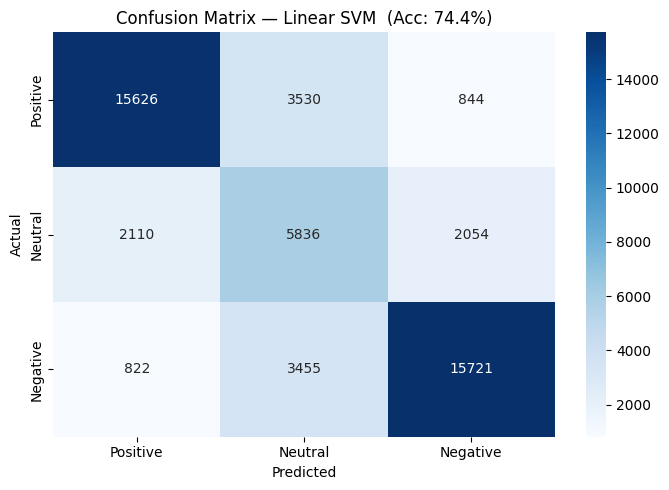

Best model (Linear SVM) saved to models/


In [ ]:
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model            import LogisticRegression
from sklearn.svm                     import LinearSVC
from sklearn.naive_bayes             import ComplementNB
from sklearn.metrics                 import classification_report, confusion_matrix, accuracy_score

train_df = pd.read_csv('data/train.csv').dropna(subset=['clean_text'])
val_df   = pd.read_csv('data/val.csv')  .dropna(subset=['clean_text'])
test_df  = pd.read_csv('data/test.csv') .dropna(subset=['clean_text'])

print('Building TF-IDF features (word + char n-grams)...')

word_tfidf = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=150000,
    sublinear_tf=True,
    min_df=2,
)
char_tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=100000,
    sublinear_tf=True,
    min_df=3,
)

print('  Fitting word TF-IDF...')
X_train_word = word_tfidf.fit_transform(train_df['clean_text'])
X_val_word   = word_tfidf.transform(val_df  ['clean_text'])
X_test_word  = word_tfidf.transform(test_df ['clean_text'])

print('  Fitting char TF-IDF...')
X_train_char = char_tfidf.fit_transform(train_df['clean_text'])
X_val_char   = char_tfidf.transform(val_df  ['clean_text'])
X_test_char  = char_tfidf.transform(test_df ['clean_text'])

X_train = hstack([X_train_word, X_train_char])
X_val   = hstack([X_val_word,   X_val_char])
X_test  = hstack([X_test_word,  X_test_char])

y_train = train_df['target'].values
y_val   = val_df  ['target'].values
y_test  = test_df ['target'].values

print(f'Feature matrix: {X_train.shape[0]:,} samples x {X_train.shape[1]:,} features')

models = [
    (LogisticRegression(max_iter=1000, C=3.0, solver='lbfgs',
                        multi_class='multinomial', n_jobs=-1),  'Logistic Regression'),
    (LinearSVC(C=0.3, max_iter=3000),                           'Linear SVM'),
    (ComplementNB(alpha=0.1),                                   'Complement Naive Bayes'),
]

results = {}
best_acc, best_model, best_name = 0, None, ''
label_names = [IDX_TO_LABEL[i] for i in range(NUM_CLASSES)]

for clf, name in models:
    print(f'\nTraining {name}...')
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f'  Test Accuracy: {acc:.4f}  ({acc*100:.1f}%)')
    if acc > best_acc:
        best_acc, best_model, best_name = acc, clf, name

print('\n── Results ──────────────────────────────────────')
for name, acc in results.items():
    marker = '  ← BEST' if name == best_name else ''
    bar = '█' * int(acc * 40)
    print(f'  {name:<30} {acc*100:5.1f}%  {bar}{marker}')

y_pred_best = best_model.predict(X_test)
print(f'\nClassification Report ({best_name}):')
print(classification_report(y_test, y_pred_best, target_names=label_names))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names, cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}  (Acc: {best_acc*100:.1f}%)')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

with open('models/best_classical_model.pkl', 'wb') as f: pickle.dump(best_model, f)
with open('models/word_tfidf.pkl',           'wb') as f: pickle.dump(word_tfidf, f)
with open('models/char_tfidf.pkl',           'wb') as f: pickle.dump(char_tfidf, f)
print(f'Best model ({best_name}) saved to models/')


In [ ]:
app_code = '''
import os, re, pickle, torch, nltk, streamlit as st
import torch.nn as nn
from scipy.sparse import hstack
from nltk.corpus  import stopwords
from nltk.stem    import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)

STOP_WORDS   = set(stopwords.words('english'))
LEMMATIZER   = WordNetLemmatizer()
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IDX_TO_LABEL = {0:'Positive', 1:'Neutral', 2:'Negative'}
NUM_CLASSES  = 3

CFG = {
    'Positive': {'emoji':'😊','color':'#2ecc71'},
    'Neutral':  {'emoji':'😐','color':'#95a5a6'},
    'Negative': {'emoji':'😠','color':'#e74c3c'},
}

def clean(text):
    text = re.sub(r'<.*?>',   '', text.lower())
    text = re.sub(r'http\\S+','', text)
    text = re.sub(r'[^a-z\\s]','',text)
    text = re.sub(r'\\s+',' ', text).strip()
    return ' '.join([LEMMATIZER.lemmatize(t) for t in text.split() if t not in STOP_WORDS])

class SimpleBertClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)
    def forward(self, input_ids, attention_mask):
        return self.classifier(
            self.bert(input_ids=input_ids, attention_mask=attention_mask).pooler_output
        )

@st.cache_resource
def load_ml():
    if not os.path.exists('models/best_classical_model.pkl'): return None, None, None
    with open('models/best_classical_model.pkl','rb') as f: clf        = pickle.load(f)
    with open('models/word_tfidf.pkl',           'rb') as f: word_tfidf = pickle.load(f)
    with open('models/char_tfidf.pkl',           'rb') as f: char_tfidf = pickle.load(f)
    return clf, word_tfidf, char_tfidf

def pred_ml(text, clf, word_tf, char_tf):
    c   = clean(text)
    vec = hstack([word_tf.transform([c]), char_tf.transform([c])])
    idx = int(clf.predict(vec)[0])
    if hasattr(clf,'predict_proba'):
        p = clf.predict_proba(vec)[0]
        conf = {IDX_TO_LABEL[i]:float(p[i])*100 for i in range(NUM_CLASSES)}
    else:
        conf = {IDX_TO_LABEL[i]:(100.0 if i==idx else 0.0) for i in range(NUM_CLASSES)}
    return IDX_TO_LABEL[idx], conf

st.set_page_config(page_title='Feedback Analyzer', page_icon='💬', layout='centered')
st.markdown('<h1 style="text-align:center">💬 Customer Feedback Analyzer</h1>', unsafe_allow_html=True)
st.markdown('---')

text   = st.text_area('Enter Feedback:', placeholder='Type any customer feedback...', height=150)

if st.button('Analyze', use_container_width=True):
    if not text.strip():
        st.warning('Please enter feedback.')
    else:
        with st.spinner('Analyzing...'):
          clf, word_tf, char_tf = load_ml()
          if clf is None: st.error('Classical model not found. Run Section 4.'); st.stop()
          label, conf = pred_ml(text, clf, word_tf, char_tf)
        c = CFG[label]
        st.markdown(
            f'<div style="background:{c["color"]}22;border:2px solid {c["color"]};'
            f'border-radius:12px;padding:1.5rem;text-align:center;margin:1rem 0">'
            f'<div style="font-size:3rem">{c["emoji"]}</div>'
            f'<div style="font-size:2rem;font-weight:700;color:{c["color"]}">{label}</div></div>',
            unsafe_allow_html=True
        )
'''
with open('app.py', 'w') as f:
    f.write(app_code)
print('app.py written successfully.')


app.py written successfully.


In [ ]:
import subprocess, time
from google.colab.output import eval_js

get_ipython().system('pkill -f streamlit 2>/dev/null')
time.sleep(2)

proc = subprocess.Popen(
    ['streamlit', 'run', 'app.py',
     '--server.port', '8501',
     '--server.headless', 'true',
     '--server.enableCORS', 'false',
     '--server.enableXsrfProtection', 'false'],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
time.sleep(5)

print('=' * 55)
print('Streamlit App is LIVE!')
print('Click the link below to open the app:')
print(eval_js('google.colab.kernel.proxyPort(8501)'))
print('=' * 55)
print('To stop: proc.terminate()')

^C
Streamlit App is LIVE!
Click the link below to open the app:
https://8501-gpu-t4-s-kkb-euw4c1-1lplbhezoav5y-c.europe-west4-1.prod.colab.dev
To stop: proc.terminate()
